<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/01-data-preprocessing/imbalance-data-treatment/Imbalanced_Dataset_Treatments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imbalanced Dataset Treatments

## Import necessary libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# !pip install imbalanced-learn

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

## Load the dataset

In [2]:
breast_cancer = load_breast_cancer()
df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Exploratory Data Analysis

In [3]:
breast_cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [4]:
df['target'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

In [5]:
print(df['target'].value_counts())
print()
print(round(df['target'].value_counts(normalize=True), 2) * 100)

target
Benign       357
Malignant    212
Name: count, dtype: int64

target
Benign       63.0
Malignant    37.0
Name: proportion, dtype: float64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [8]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

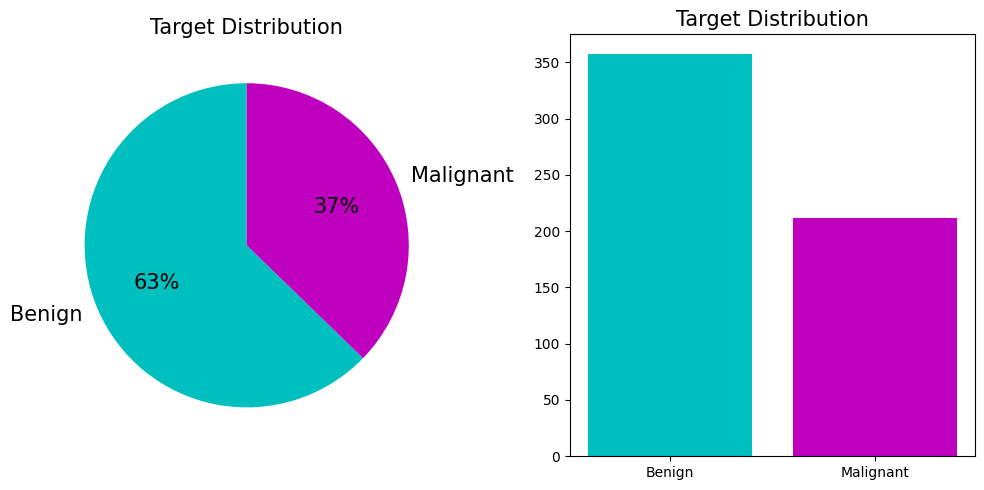

In [29]:
fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

colors = ['c', 'm']
axis[0].pie(df['target'].value_counts(), labels=df['target'].value_counts().index, colors=colors, autopct='%.0f%%', textprops={'fontsize': 15}, startangle=90)
axis[0].set_title('Target Distribution', fontsize=15)

axis[1].bar(df['target'].value_counts().index, df['target'].value_counts(), color=colors)
axis[1].set_title('Target Distribution', fontsize=15)

plt.tight_layout()
plt.show()

In [17]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


In [61]:
def plot_distribution(y_resampled, title):
    plt.figure(figsize=(5, 5))
    plt.pie(y_resampled.value_counts(), labels=y_resampled.value_counts().index, autopct='%.00f%%', textprops={'fontsize': 15}, colors=colors, startangle=90)
    plt.title(title)
    plt.show()

## Random Under Sampler

In [32]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

In [33]:
y_train.value_counts()

,count
target,
Benign,286
Malignant,169


In [34]:
y_rus.value_counts()

,count
target,
Benign,169
Malignant,169


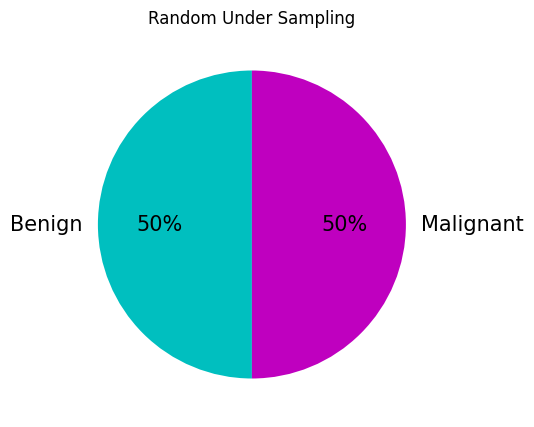

In [45]:
plot_distribution(y_rus, 'Random Under Sampling')

## Random Over Sampler

In [36]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

In [38]:
y_train.value_counts()

,count
target,
Benign,286
Malignant,169


In [37]:
y_ros.value_counts()

,count
target,
Benign,286
Malignant,286


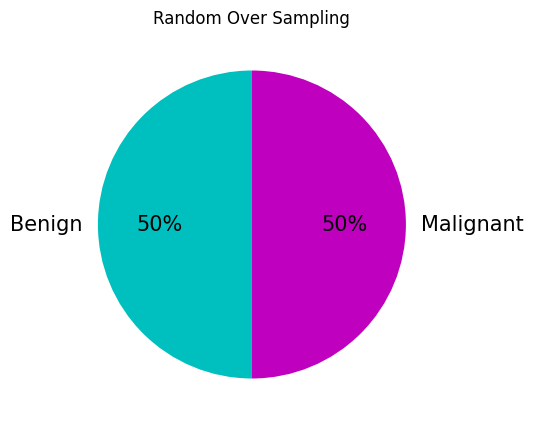

In [46]:
plot_distribution(y_ros, 'Random Over Sampling')

## Tomek

In [40]:
tom = TomekLinks()
X_tom, y_tom = tom.fit_resample(X_train, y_train)

In [41]:
y_train.value_counts()

,count
target,
Benign,286
Malignant,169


In [42]:
y_tom.value_counts()

,count
target,
Benign,275
Malignant,169


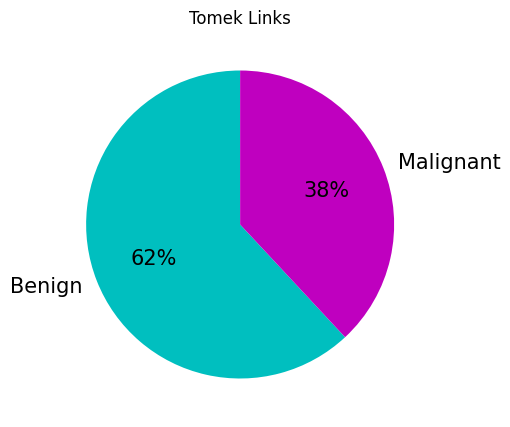

In [47]:
plot_distribution(y_tom, 'Tomek Links')

## SMOTE

In [48]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [49]:
y_train.value_counts()

,count
target,
Benign,286
Malignant,169


In [50]:
y_smote.value_counts()

,count
target,
Benign,286
Malignant,286


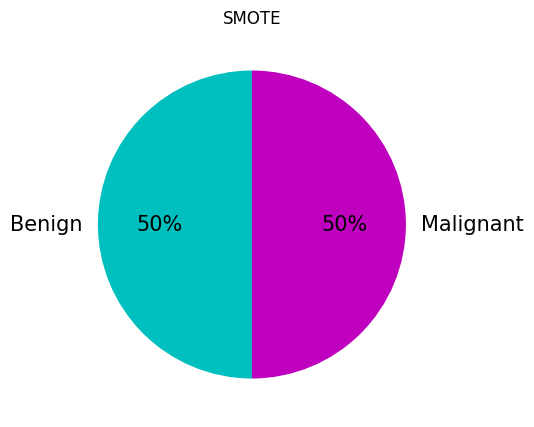

In [51]:
plot_distribution(y_smote, 'SMOTE')

## SMOTETomek

In [52]:
st = SMOTETomek(random_state=42)
X_st, y_st = st.fit_resample(X_train, y_train)

In [53]:
y_train.value_counts()

,count
target,
Benign,286
Malignant,169


In [54]:
y_st.value_counts()

,count
target,
Benign,279
Malignant,279


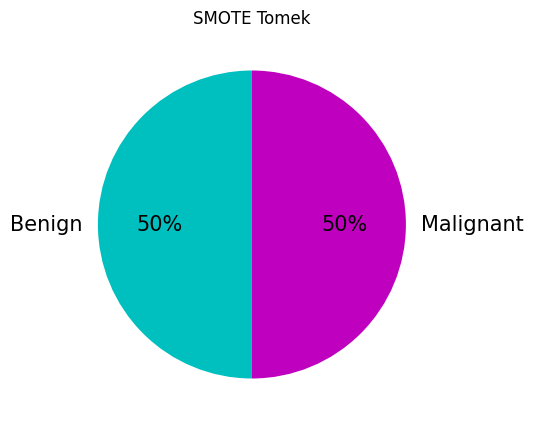

In [56]:
plot_distribution(y_st, 'SMOTE Tomek')

## ADASYN

In [57]:
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

In [58]:
y_train.value_counts()

,count
target,
Benign,286
Malignant,169


In [59]:
y_adasyn.value_counts()

,count
target,
Malignant,288
Benign,286


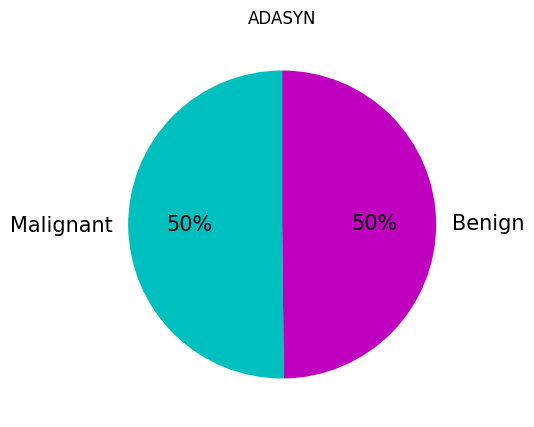

In [62]:
plot_distribution(y_adasyn, 'ADASYN')